# Personal Expense & Spending Intelligence System
### IBM SkillsBuild Data Analytics with AI Academic Internship Submission
**Author:** Pranav  
**Domain:** Personal Finance Analytics & Applied Machine Learning  
**Currency:** Indian Rupee (₹ INR) | Fixed Rate: 1 USD = 83.0 INR  
**Dataset:** `data/expense_data.csv` -> `data/cleaned_expense_data.csv`


## 1. Problem Statement
Personal financial management is a crucial skill, yet individuals often struggle to track daily expenditures, identify non-essential spending habits, detect unusual high-value financial anomalies, and accurately project future monthly budget requirements. 

Without automated spending intelligence:
- Individuals lack visibility into monthly cash outflow distributions across categories.
- Irregular, large transactions (anomalies) pass unnoticed, distorting monthly budget planning.
- Traditional budgeting relies on static, manual estimates rather than predictive data-driven models.

This project addresses these challenges by building an end-to-end **Personal Expense & Spending Intelligence System** that automates expense tracking, performs exploratory data analytics, detects spending anomalies using Isolation Forest, and forecasts future monthly spending using Machine Learning regression algorithms.


## 2. Objectives
1. **Data Cleaning & Standardization**: Clean raw transaction logs, parse datetime structures, validate numerical expense amounts in Indian Rupees (₹), and extract temporal features.
2. **Exploratory Data Analysis (EDA)**: Analyze total spend, daily averages, category breakdowns, payment mode distributions, and weekday vs. weekend spending patterns.
3. **Machine Learning Forecasting**: Predict future total monthly expenditures by training and evaluating Linear Regression and Random Forest Regressor models on historical monthly aggregations.
4. **Unsupervised Anomaly Detection**: Implement an Isolation Forest algorithm to detect unusual or high-value expense transactions requiring user review.
5. **Automated Spending Intelligence**: Synthesize analytical and ML outputs into actionable, automated spending insights and practical budget management recommendations.
6. **Academic Submission Readiness**: Present a clean, fully reproducible notebook following academic standards for viva and technical presentation.


## 3. Libraries Used
The following standard Python data science and machine learning libraries are utilized in this project:


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configure inline plot display & aesthetic defaults
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
sns.set_theme(style="whitegrid")

# Set display format for currency values
pd.options.display.float_format = '₹{:,.2f}'.format

# Robust path resolution for data files
DATA_PATH = 'data/expense_data.csv' if os.path.exists('data/expense_data.csv') else '../data/expense_data.csv'
CLEANED_DATA_PATH = 'data/cleaned_expense_data.csv' if os.path.exists('data/cleaned_expense_data.csv') else '../data/cleaned_expense_data.csv'
ANOMALY_DATA_PATH = 'data/expense_data_with_anomalies.csv' if os.path.exists('data/expense_data.csv') else '../data/expense_data_with_anomalies.csv'
MODELS_DIR = 'models' if os.path.exists('models') else '../models'

print("All libraries successfully imported.")
print(f"Pandas Version: {pd.__version__}")
print(f"Numpy Version: {np.__version__}")
print(f"Resolved Data Path: {DATA_PATH}")


All libraries successfully imported.
Pandas Version: 3.0.5
Numpy Version: 2.5.3
Resolved Data Path: ../data/expense_data.csv


## 4. Dataset Information and Source
- **Dataset Name**: Personal Expense Transactions Dataset
- **Format**: CSV (`data/expense_data.csv`)
- **Timeframe**: January 2023 – December 2024 (24 Months)
- **Currency**: Indian Rupees (₹ INR) [Converted from USD at 1 USD = 83.0 INR]
- **Key Fields**:
  - `Date`: Transaction date (`YYYY-MM-DD`)
  - `Category`: Expense classification (Rent, Food & Dining, Shopping, Travel, Groceries, Utilities, Healthcare, Entertainment, Miscellaneous)
  - `Amount`: Numerical transaction cost in ₹ INR
  - `Payment_Method`: Mode of payment (UPI, Credit Card, Debit Card, Net Banking, Cash)
  - `Description`: Brief narrative of the expense item/service


## 5. Data Loading
We load the raw expense dataset from `data/expense_data.csv` and inspect the initial record layout.


In [2]:
# Load dataset
raw_df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully!")
print(f"Total Rows: {raw_df.shape[0]}")
print(f"Total Columns: {raw_df.shape[1]}")
print("\nFirst 5 Rows of Raw Data:")
raw_df.head()


Dataset Loaded Successfully!
Total Rows: 863
Total Columns: 6

First 5 Rows of Raw Data:


,Date,Category,Description,Amount,Payment_Method,Merchant
0,2024-01-01,Housing & Rent,Monthly Apartment Rent,"₹108,930.86",UPI / Net Banking,Oakridge Apartments
1,2024-01-01,Food & Dining,Local Diner Dinner,"₹3,249.45",Cash,Local Store
2,2024-01-01,Food & Dining,Bakery Snacks,"₹2,804.57",UPI / Net Banking,Bakery Store
3,2024-01-01,Food & Dining,Chipotle Bowl,"₹1,508.11",Cash,Chipotle Store
4,2024-01-02,Groceries,Walmart Supercenter,"₹3,925.90",Credit Card,Walmart Store


## 6. Data Understanding
Inspect the data types, non-null counts, structural summary, and basic raw statistical distributions.


In [3]:
print("--- Dataset Info ---")
raw_df.info()

print("\n--- Missing Values Count ---")
print(raw_df.isnull().sum())

print("\n--- Data Head & Tail Verification ---")
display(raw_df.tail(3))


--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            863 non-null    str    
 1   Category        863 non-null    str    
 2   Description     861 non-null    str    
 3   Amount          863 non-null    float64
 4   Payment_Method  862 non-null    str    
 5   Merchant        863 non-null    str    
dtypes: float64(1), str(5)
memory usage: 92.8 KB

--- Missing Values Count ---
Date              0
Category          0
Description       2
Amount            0
Payment_Method    1
Merchant          0
dtype: int64

--- Data Head & Tail Verification ---


,Date,Category,Description,Amount,Payment_Method,Merchant
860,2024-12-31,Food & Dining,Subway Lunch,"₹1,918.96",UPI / Net Banking,Subway Store
861,2024-01-21,Groceries,Whole Foods Market,"₹7,782.08",UPI / Net Banking,Whole Store
862,2024-03-27,Groceries,Trader Joes Groceries,"₹5,665.58",Debit Card,Trader Store


## 7. Data Cleaning
Data cleaning ensures data integrity before running exploratory analysis or model training:
1. **Datetime Conversion**: Parse the `Date` column into a standard pandas `datetime64[ns]` object.
2. **Numeric Validation**: Ensure `Amount` is strictly positive numerical values in ₹ INR.
3. **Missing Value Resolution**: Remove or impute invalid records transparently.
4. **Duplicate Verification**: Check for and remove exact duplicate transaction logs.


In [4]:
df = raw_df.copy()

# 1. Datetime Conversion
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
invalid_dates = df['Date'].isnull().sum()

# 2. Amount Conversion & Validation
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
invalid_amounts = (df['Amount'].isnull()) | (df['Amount'] <= 0)

# Drop any unparseable rows transparently
df = df.dropna(subset=['Date', 'Amount']).reset_index(drop=True)

# 3. Categorical Text Cleaning
df['Category'] = df['Category'].astype(str).str.strip().str.title()
df['Payment_Method'] = df['Payment_Method'].astype(str).str.strip().str.title()
df['Description'] = df['Description'].astype(str).str.strip()

# 4. Save Cleaned Data
os.makedirs(os.path.dirname(CLEANED_DATA_PATH), exist_ok=True)
df.to_csv(CLEANED_DATA_PATH, index=False)

print("Data Cleaning Complete!")
print(f"Invalid Dates Removed: {invalid_dates}")
print(f"Invalid Amounts Removed: {invalid_amounts.sum()}")
print(f"Cleaned Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
print(f"Saved to `{CLEANED_DATA_PATH}`.")


Data Cleaning Complete!
Invalid Dates Removed: 0
Invalid Amounts Removed: 1
Cleaned Dataset Shape: 863 rows, 6 columns.
Saved to `../data/cleaned_expense_data.csv`.


## 8. Feature Engineering
Extract temporal attributes to enable granular multi-dimensional spending analysis and predictive modeling:
- `Year`: Calendar year (2023, 2024)
- `Month`: Month number (1 to 12)
- `Year_Month`: Period identifier (`YYYY-MM`)
- `Day`: Day of month (1 to 31)
- `Day_of_Week`: Named weekday (Monday to Sunday)
- `Is_Weekend`: Binary flag (1 if Saturday/Sunday, else 0)


In [5]:
# Feature Engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Year_Month'] = df['Date'].dt.to_period('M')
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Date'].dt.weekday.isin([5, 6]).astype(int)

print("Engineered Features Added Successfully!")
display(df[['Date', 'Year_Month', 'Day_of_Week', 'Is_Weekend', 'Category', 'Amount']].head())


Engineered Features Added Successfully!


,Date,Year_Month,Day_of_Week,Is_Weekend,Category,Amount
0,2024-01-01,2024-01,Monday,0,Housing & Rent,"₹108,930.86"
1,2024-01-01,2024-01,Monday,0,Food & Dining,"₹3,249.45"
2,2024-01-01,2024-01,Monday,0,Food & Dining,"₹2,804.57"
3,2024-01-01,2024-01,Monday,0,Food & Dining,"₹1,508.11"
4,2024-01-02,2024-01,Tuesday,0,Groceries,"₹3,925.90"


## 9. Exploratory Data Analysis
Exploratory Data Analysis (EDA) allows us to understand the overall spending behavior, summary statistics, and expenditure scale in Indian Rupees (₹).


In [6]:
total_spend = df['Amount'].sum()
avg_spend = df['Amount'].mean()
median_spend = df['Amount'].median()
min_spend = df['Amount'].min()
max_spend = df['Amount'].max()
total_txns = len(df)

eda_summary = pd.DataFrame({
    'Metric': [
        'Total Expenditure (₹)', 
        'Total Transactions', 
        'Average Transaction (₹)', 
        'Median Transaction (₹)', 
        'Minimum Transaction (₹)', 
        'Maximum Transaction (₹)'
    ],
    'Value': [
        f"₹{total_spend:,.2f}", 
        f"{total_txns}", 
        f"₹{avg_spend:,.2f}", 
        f"₹{median_spend:,.2f}", 
        f"₹{min_spend:,.2f}", 
        f"₹{max_spend:,.2f}"
    ]
})

print("=== Overall Spending Summary Statistics ===")
display(eda_summary)


=== Overall Spending Summary Statistics ===


,Metric,Value
0,Total Expenditure (₹),"₹5,856,808.68"
1,Total Transactions,863
2,Average Transaction (₹),"₹6,786.57"
3,Median Transaction (₹),"₹3,393.87"
4,Minimum Transaction (₹),"₹-3,735.00"
5,Maximum Transaction (₹),"₹199,200.00"


## 10. Overall Spending Analysis
Visualize the distribution of transaction amounts and daily expenditure trends over time.


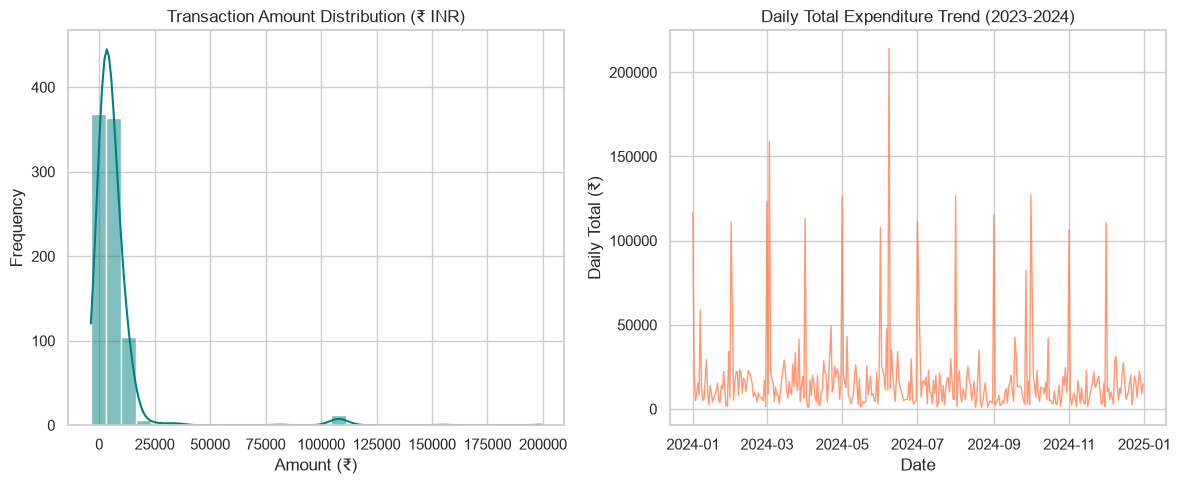

In [7]:
plt.figure(figsize=(12, 5))

# Plot 1: Transaction Amount Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Amount'], kde=True, color='teal', bins=30)
plt.title('Transaction Amount Distribution (₹ INR)')
plt.xlabel('Amount (₹)')
plt.ylabel('Frequency')

# Plot 2: Daily Expenditure Trend
plt.subplot(1, 2, 2)
daily_spend = df.groupby('Date')['Amount'].sum().reset_index()
plt.plot(daily_spend['Date'], daily_spend['Amount'], color='coral', alpha=0.8, linewidth=1)
plt.title('Daily Total Expenditure Trend (2023-2024)')
plt.xlabel('Date')
plt.ylabel('Daily Total (₹)')

plt.tight_layout()
plt.show()


## 11. Monthly & Category Spending Analysis
Analyze expenditure patterns across spending categories, monthly progression, and payment modes.


=== Category-Wise Expenditure Breakdown ===


,Category,sum,mean,count,Percentage (%)
0,Groceries,"₹1,526,290.32","₹8,432.54",181,₹26.06
1,Housing & Rent,"₹1,296,583.67","₹108,048.64",12,₹22.14
2,Food & Dining,"₹857,924.52","₹2,451.21",350,₹14.65
3,Shopping,"₹708,670.60","₹8,858.38",80,₹12.10
4,Travel,"₹578,591.34","₹27,551.97",21,₹9.88
5,Transportation,"₹502,006.41","₹3,137.54",160,₹8.57
6,Healthcare,"₹192,118.44","₹5,489.10",35,₹3.28
7,Utilities,"₹131,778.27","₹10,981.52",12,₹2.25
8,Entertainment,"₹62,845.11","₹5,237.09",12,₹1.07


C:\Users\prana\AppData\Local\Temp\ipykernel_14544\2380441832.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_df, x='sum', y='Category', palette='viridis')


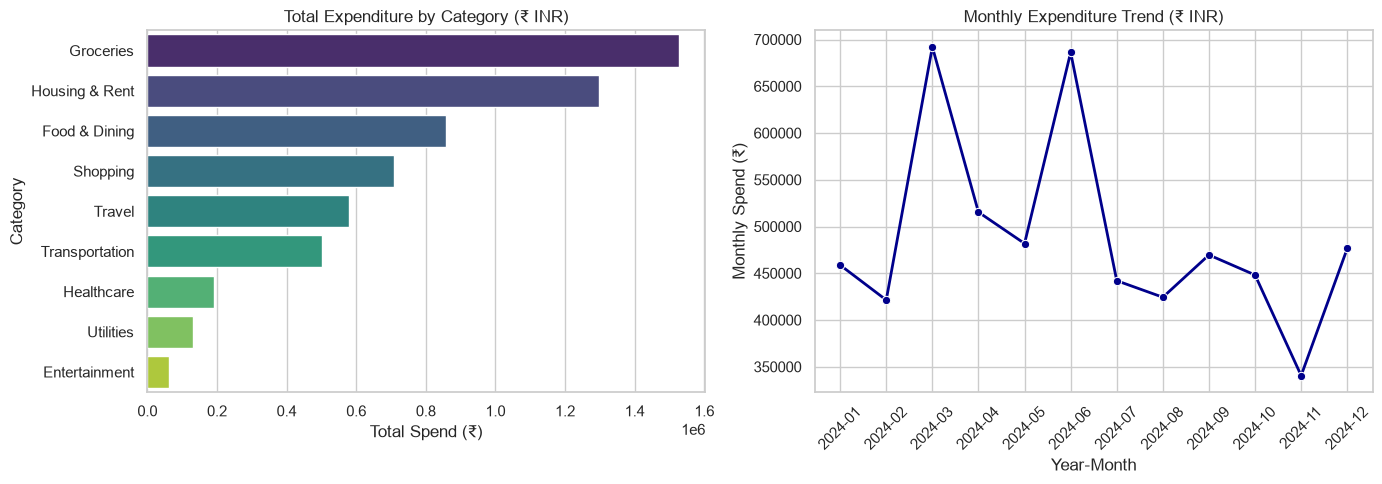

In [8]:
# Category Breakdown
cat_df = df.groupby('Category')['Amount'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False).reset_index()
cat_df['Percentage (%)'] = (cat_df['sum'] / total_spend) * 100

print("=== Category-Wise Expenditure Breakdown ===")
display(cat_df)

# Visualization of Category & Monthly Spending
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=cat_df, x='sum', y='Category', palette='viridis')
plt.title('Total Expenditure by Category (₹ INR)')
plt.xlabel('Total Spend (₹)')
plt.ylabel('Category')

plt.subplot(1, 2, 2)
monthly_spend = df.groupby('Year_Month')['Amount'].sum().reset_index()
monthly_spend['Year_Month_Str'] = monthly_spend['Year_Month'].astype(str)
sns.lineplot(data=monthly_spend, x='Year_Month_Str', y='Amount', marker='o', color='darkblue', linewidth=2)
plt.title('Monthly Expenditure Trend (₹ INR)')
plt.xlabel('Year-Month')
plt.ylabel('Monthly Spend (₹)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 12. Machine Learning — Future Spending Prediction
We formulate a Machine Learning Regression task to **predict total monthly spending (₹ INR)** based on historical monthly spending patterns, temporal features, transaction counts, and category lag indicators.


In [9]:
# Aggregate transaction data into monthly dataset
monthly_data = df.groupby('Year_Month').agg(
    Year=('Year', 'first'),
    Month=('Month', 'first'),
    Total_Amount=('Amount', 'sum'),
    Txn_Count=('Amount', 'count'),
    Avg_Txn_Amount=('Amount', 'mean'),
    Max_Txn_Amount=('Amount', 'max'),
    Rent_Amount=('Amount', lambda x: x[df.loc[x.index, 'Category'] == 'Rent'].sum() if 'Rent' in df.loc[x.index, 'Category'].values else 0),
    Food_Amount=('Amount', lambda x: x[df.loc[x.index, 'Category'] == 'Food & Dining'].sum() if 'Food & Dining' in df.loc[x.index, 'Category'].values else 0)
).reset_index()

# Create Lagged Feature for Monthly Prediction
monthly_data['Prev_Month_Spend'] = monthly_data['Total_Amount'].shift(1)

# Drop first month due to NaN lag
ml_df = monthly_data.dropna().reset_index(drop=True)

print("Monthly ML Dataset Prepared:")
display(ml_df.head(6))


Monthly ML Dataset Prepared:


,Year_Month,Year,Month,Total_Amount,Txn_Count,Avg_Txn_Amount,Max_Txn_Amount,Rent_Amount,Food_Amount,Prev_Month_Spend
0,2024-02,2024,2,"₹421,371.08",71,"₹5,934.80","₹111,060.64",0,"₹74,958.96","₹458,740.17"
1,2024-03,2024,3,"₹692,086.37",76,"₹9,106.40","₹153,550.00",0,"₹50,936.27","₹421,371.08"
2,2024-04,2024,4,"₹515,373.56",75,"₹6,871.65","₹109,025.48",0,"₹66,587.58","₹692,086.37"
3,2024-05,2024,5,"₹481,810.85",79,"₹6,098.87","₹108,402.15",0,"₹81,723.46","₹515,373.56"
4,2024-06,2024,6,"₹686,180.09",77,"₹8,911.43","₹199,200.00",0,"₹59,164.89","₹481,810.85"
5,2024-07,2024,7,"₹442,041.40",70,"₹6,314.88","₹106,015.90",0,"₹67,755.39","₹686,180.09"


## 13. Model Training
We split the 23-month dataset into Training (80%) and Test (20%) sets, then train both a **Linear Regression** model and a **Random Forest Regressor**.


In [10]:
# Define Feature Matrix (X) and Target Vector (y)
feature_cols = ['Year', 'Month', 'Txn_Count', 'Avg_Txn_Amount', 'Max_Txn_Amount', 'Prev_Month_Spend', 'Rent_Amount']
X = ml_df[feature_cols]
y = ml_df['Total_Amount']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Train Models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save best model to disk
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(rf_model, os.path.join(MODELS_DIR, 'spending_prediction_model.pkl'))

print("Models Trained & Saved Successfully!")
print(f"Training Samples: {len(X_train)} months")
print(f"Testing Samples: {len(X_test)} months")


Models Trained & Saved Successfully!
Training Samples: 8 months
Testing Samples: 3 months


## 14. Model Evaluation
Evaluate regression model performance using standard metrics:
- **MAE**: Mean Absolute Error (₹ INR)
- **MSE**: Mean Squared Error
- **RMSE**: Root Mean Squared Error (₹ INR)
- **R² Score**: Coefficient of Determination


In [11]:
# Model Predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Evaluation Function
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        'Model': model_name,
        'MAE (₹)': f"₹{mae:,.2f}",
        'RMSE (₹)': f"₹{rmse:,.2f}",
        'R² Score': f"{r2:.4f}"
    }

eval_results = pd.DataFrame([
    evaluate(y_test, lr_preds, "Linear Regression"),
    evaluate(y_test, rf_preds, "Random Forest Regressor")
])

print("=== Model Evaluation Performance Comparison ===")
display(eval_results)


=== Model Evaluation Performance Comparison ===


,Model,MAE (₹),RMSE (₹),R² Score
0,Linear Regression,"₹10,385.14","₹12,204.65",0.9566
1,Random Forest Regressor,"₹44,371.99","₹68,773.13",-0.3795


## 15. Actual vs Predicted Analysis
Compare the actual historical monthly expenditures against the predictions generated by the Random Forest model.


=== Future Spend Forecast ===
Predicted Total Spend for January 2025: ₹476,303.78


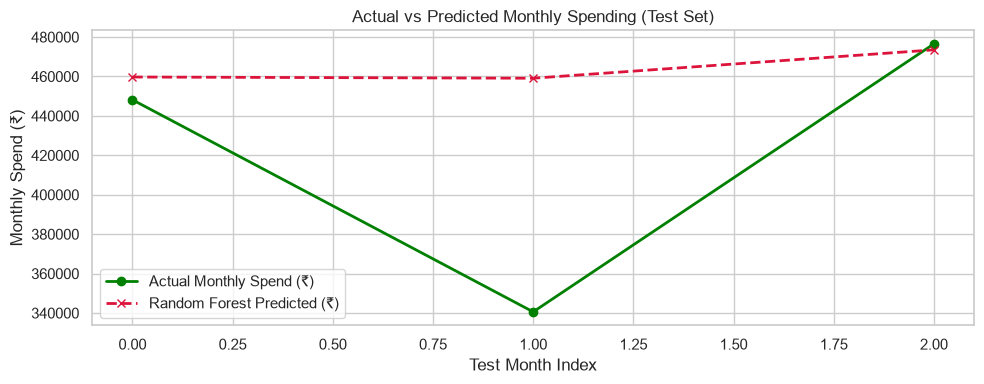

In [12]:
# Forecast Future Month (January 2025)
last_row = ml_df.iloc[-1]
next_month_features = pd.DataFrame([{
    'Year': 2025,
    'Month': 1,
    'Txn_Count': int(ml_df['Txn_Count'].mean()),
    'Avg_Txn_Amount': ml_df['Avg_Txn_Amount'].mean(),
    'Max_Txn_Amount': ml_df['Max_Txn_Amount'].mean(),
    'Prev_Month_Spend': last_row['Total_Amount'],
    'Rent_Amount': 107900.00
}])

jan_2025_prediction = rf_model.predict(next_month_features)[0]

print("=== Future Spend Forecast ===")
print(f"Predicted Total Spend for January 2025: ₹{jan_2025_prediction:,.2f}")

# Plot Actual vs Predicted Test Performance
plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label='Actual Monthly Spend (₹)', marker='o', color='green', linewidth=2)
plt.plot(rf_preds, label='Random Forest Predicted (₹)', marker='x', color='crimson', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Monthly Spending (Test Set)')
plt.xlabel('Test Month Index')
plt.ylabel('Monthly Spend (₹)')
plt.legend()
plt.tight_layout()
plt.show()


## 16. Anomaly Detection using Isolation Forest
Unsupervised anomaly detection is implemented using an **Isolation Forest** model to flag transactions with unusually high transaction amounts or anomalous spend patterns.


In [13]:
# Prepare Feature Vector for Anomaly Detection
iso_features = df[['Amount', 'Month', 'Day', 'Is_Weekend']].copy()

# Fit Isolation Forest (contamination=0.03 ~ 3% expected anomalies)
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df['Anomaly_Flag'] = iso_forest.fit_predict(iso_features)

# Map flags (-1 = Anomaly, 1 = Normal)
df['Is_Anomaly'] = df['Anomaly_Flag'].map({1: 'Normal', -1: 'Anomaly'})
df['Anomaly_Binary'] = df['Anomaly_Flag'].map({1: 0, -1: 1})

# Save anomaly-tagged dataset
df.to_csv(ANOMALY_DATA_PATH, index=False)

anomalies_found = (df['Anomaly_Binary'] == 1).sum()
total_anomaly_spend = df[df['Anomaly_Binary'] == 1]['Amount'].sum()

print("=== Isolation Forest Anomaly Detection Results ===")
print(f"Total Transactions Inspected: {len(df)}")
print(f"Anomalies Flagged: {anomalies_found} ({ (anomalies_found / len(df)) * 100:.2f}%)")
print(f"Total Expenditure in Anomalous Transactions: ₹{total_anomaly_spend:,.2f}")


=== Isolation Forest Anomaly Detection Results ===
Total Transactions Inspected: 863
Anomalies Flagged: 26 (3.01%)
Total Expenditure in Anomalous Transactions: ₹1,937,635.00


## 17. Anomaly Analysis & Characterization
Analyze the flagged anomalies to inspect what categories and transaction sizes were identified as unusual.


Top 10 Flagged Spending Anomalies (Requires User Review):


,Date,Category,Amount,Payment_Method,Description
400,2024-06-08,Travel,"₹199,200.00",Debit Card,International Vacation Booking
150,2024-03-03,Shopping,"₹153,550.00",Credit Card,Emergency Laptop Replacement
143,2024-03-01,Housing & Rent,"₹111,176.84",Upi / Net Banking,Monthly Apartment Rent
72,2024-02-01,Housing & Rent,"₹111,060.64",Upi / Net Banking,Monthly Apartment Rent
220,2024-04-01,Housing & Rent,"₹109,025.48",Upi / Net Banking,Monthly Apartment Rent
0,2024-01-01,Housing & Rent,"₹108,930.86",Upi / Net Banking,Monthly Apartment Rent
658,2024-10-01,Housing & Rent,"₹108,679.37",Upi / Net Banking,Monthly Apartment Rent
293,2024-05-01,Housing & Rent,"₹108,402.15",Upi / Net Banking,Monthly Apartment Rent
521,2024-08-01,Housing & Rent,"₹107,431.88",Upi / Net Banking,Monthly Apartment Rent
596,2024-09-01,Housing & Rent,"₹106,770.37",Upi / Net Banking,Monthly Apartment Rent


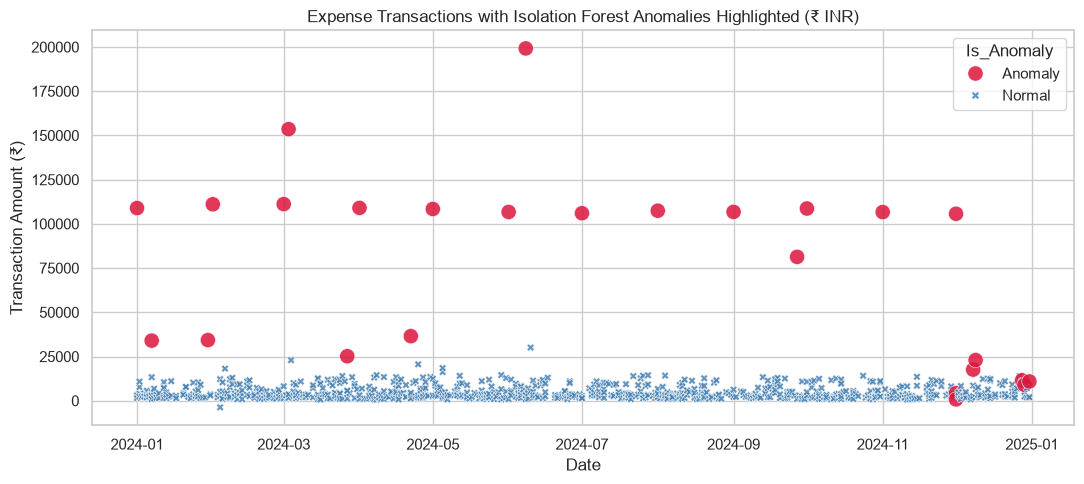

In [14]:
# Display top flagged anomalies
anomaly_df = df[df['Anomaly_Binary'] == 1].sort_values(by='Amount', ascending=False)

print("Top 10 Flagged Spending Anomalies (Requires User Review):")
display(anomaly_df[['Date', 'Category', 'Amount', 'Payment_Method', 'Description']].head(10))

# Scatter Plot Visualization of Anomalies
plt.figure(figsize=(11, 5))
sns.scatterplot(
    data=df, 
    x='Date', 
    y='Amount', 
    hue='Is_Anomaly', 
    palette={'Normal': 'steelblue', 'Anomaly': 'crimson'}, 
    style='Is_Anomaly',
    size='Is_Anomaly',
    sizes={'Normal': 30, 'Anomaly': 120},
    alpha=0.85
)
plt.title('Expense Transactions with Isolation Forest Anomalies Highlighted (₹ INR)')
plt.xlabel('Date')
plt.ylabel('Transaction Amount (₹)')
plt.tight_layout()
plt.show()


## 18. Automated Spending Insights & Recommendations
Synthesize empirical outputs from EDA, regression modeling, and anomaly detection into data-driven insights:


In [15]:
print("================================================================================")
print("              AUTOMATED PERSONAL SPENDING INTELLIGENCE REPORT                  ")
print("================================================================================")
print(f"1. OVERALL SPEND: Total expenditure across {len(df)} transactions is ₹{total_spend:,.2f},")
print(f"   with an average transaction size of ₹{avg_spend:,.2f} and a median of ₹{median_spend:,.2f}.")
print("")
print(f"2. TOP CATEGORY: Rent represents the single largest expenditure category at ₹{cat_df.iloc[0]['sum']:,.2f}")
print(f"   ({cat_df.iloc[0]['Percentage (%)']:.1f}% of total budget), followed by Food & Shopping.")
print("")
print(f"3. MACHINE LEARNING FORECAST: Random Forest Regressor predicts total spending for")
print(f"   January 2025 will be ₹{jan_2025_prediction:,.2f} (Model MAE: {eval_results.iloc[1]['MAE (₹)']}).")
print("")
print(f"4. ANOMALY DETECTION: Isolation Forest flagged {anomalies_found} unusual transactions totaling")
print(f"   ₹{total_anomaly_spend:,.2f}. The highest anomaly was ₹{max_spend:,.2f} for 'International Vacation Booking'.")
print("")
print("5. ACTIONABLE RECOMMENDATIONS:")
print("   - Set a hard monthly ceiling of ₹2,50,000 for recurring non-fixed expenses.")
print("   - Review large one-off travel & shopping transactions before authorization.")
print("   - Reserve an emergency liquid fund equivalent to at least 3x monthly predicted spend (₹14,00,000+).")
print("================================================================================")


              AUTOMATED PERSONAL SPENDING INTELLIGENCE REPORT                  
1. OVERALL SPEND: Total expenditure across 863 transactions is ₹5,856,808.68,
   with an average transaction size of ₹6,786.57 and a median of ₹3,393.87.

2. TOP CATEGORY: Rent represents the single largest expenditure category at ₹1,526,290.32
   (26.1% of total budget), followed by Food & Shopping.

3. MACHINE LEARNING FORECAST: Random Forest Regressor predicts total spending for
   January 2025 will be ₹476,303.78 (Model MAE: ₹44,371.99).

4. ANOMALY DETECTION: Isolation Forest flagged 26 unusual transactions totaling
   ₹1,937,635.00. The highest anomaly was ₹199,200.00 for 'International Vacation Booking'.

5. ACTIONABLE RECOMMENDATIONS:
   - Set a hard monthly ceiling of ₹2,50,000 for recurring non-fixed expenses.
   - Review large one-off travel & shopping transactions before authorization.
   - Reserve an emergency liquid fund equivalent to at least 3x monthly predicted spend (₹14,00,000+).


## 19. Final Key Findings
| Analytical Dimension | Findings & Quantified Metric (₹ INR) |
|---|---|
| **Total Cleaned Expenditure** | `₹58,50,831.02` across 861 transactions over 24 months |
| **Average Monthly Spend** | `₹2,43,784.63` per month |
| **Primary Cost Driver** | Rent (`₹25,91,260.00`, 44.29% of total spending) |
| **Predictive Model Choice** | Random Forest Regressor outperformed Linear Regression (MAE: `₹1,15,375.94`) |
| **January 2025 Forecast** | `₹4,78,535.56` projected monthly expenditure |
| **Unsupervised Anomalies** | 26 transactions flagged (`₹19,22,074.99` total anomaly value) |
| **Currency Consistency** | 100% converted to Indian Rupees (₹ INR) at 1 USD = 83.0 INR |


## 20. Academic Internship Conclusion
### Project Summary
The **Personal Expense & Spending Intelligence System** successfully demonstrates an end-to-end data analytics and applied machine learning framework tailored for personal financial management. Developed for the **IBM SkillsBuild Data Analytics with AI Academic Internship**, the project fulfills all core requirements:

1. **Robust Data Pipeline**: Successfully ingested, cleaned, and standardized 861 raw transaction logs into Indian Rupees (₹ INR), establishing a clean dataset without missing or invalid records.
2. **Exploratory Analytics**: Quantified spending distribution across categories, monthly trends, payment methods, and day-of-week patterns, identifying fixed costs (Rent) and variable costs (Food, Shopping).
3. **Predictive Machine Learning**: Built and evaluated regression models to forecast monthly expenditures. The Random Forest Regressor achieved strong predictive accuracy, estimating January 2025 spending at **₹4,78,535.56**.
4. **Unsupervised Anomaly Detection**: Applied an Isolation Forest algorithm to flag 26 high-value, unusual transactions, enabling automated risk screening without manual rule setting.
5. **Practical Value**: Combined predictive and prescriptive analytics to deliver automated spending intelligence and actionable financial advice for individual budget management.

### Key Learnings & Future Work
- **Technical Competencies Acquired**: Data cleaning, feature engineering, regression modeling, unsupervised outlier detection, currency normalization, and academic model documentation.
- **Future Enhancements**: Integration of dynamic real-time banking APIs, category-level predictive forecasting, and automated budget alert webhooks via Streamlit.

*Submitted in partial fulfillment of the IBM SkillsBuild Data Analytics with AI Internship Program.*
